# 🔦 GASMAS — Internal Illumination

**Technique:** GASMAS (Gas in Scattering Media Absorption Spectroscopy)  
**Mode:** Internal illumination — isotropic (diffusing probe) source inside thorax tissue  
**Gas:** O₂ at 763.84 nm (A-band), scan ±0.025 nm  
**Geometry:** Three-region volume (8×8×7 cm total):

**Source:** Diffusing probe at x=65 mm, y=40 mm, z=50 mm  
(centred laterally in thorax half, 2 cm below thorax/lung interface, 2 cm above bottom)  
**Detectors:** Array on top surface (z=1), spanning 8 cm at 1 cm intervals

---
### Pipeline
```
HITRAN/HAPI → O2 absorption spectrum α(λ)
MCX         → photon pathlength in air pockets → GASMAS
```
### ⚠️ Enable T4 GPU: Runtime → Change runtime type → T4 GPU

## Cell 1 — Install Dependencies

In [1]:
!pip install pmcx hitran-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
import time, os

import pmcx
print('pmcx version:', pmcx.__version__)

try:
    gpu_info = pmcx.gpuinfo()
    print('GPU:', gpu_info)
except:
    print('No GPU — running on CPU')

import hapi
print('HAPI imported ✓')

pmcx version: 0.7.1
GPU: [{'name': 'Tesla T4', 'id': 1, 'devcount': 1, 'major': 7, 'minor': 5, 'globalmem': 15637086208, 'constmem': 65536, 'sharedmem': 49152, 'regcount': 65536, 'clock': 1590000, 'sm': 40, 'core': 2560, 'autoblock': 64, 'autothread': 81920, 'maxgate': 0}]
HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

        

## Cell 2 — Download O₂ Line Data from HITRAN via HAPI

> **Wavenumber range for ±0.025 nm around 763.84 nm:**  
> λ = 763.815 – 763.865 nm → ν = 13089.0 – 13089.9 cm⁻¹

In [10]:
# ── Spectral range ────────────────────────────────────────────
LAMBDA_CENTER_NM = 763.84251         # O2 A-band peak (nm)
SCAN_HALF_NM     = 0.025             # ±0.025 nm

lambda_min_nm = LAMBDA_CENTER_NM - SCAN_HALF_NM
lambda_max_nm = LAMBDA_CENTER_NM + SCAN_HALF_NM

nu_min = 1e7 / lambda_max_nm
nu_max = 1e7 / lambda_min_nm
NU_STEP = 0.0001

print(f'Wavelength range : {lambda_min_nm:.4f} – {lambda_max_nm:.4f} nm')
print(f'Wavenumber range : {nu_min:.4f} – {nu_max:.4f} cm⁻¹')

HAPI_DIR = './hapi_data'
os.makedirs(HAPI_DIR, exist_ok=True)
hapi.db_begin(HAPI_DIR)

print('\nDownloading O2 line data from HITRAN...')
hapi.fetch('O2_Aband', 7, 1, nu_min - 2.0, nu_max + 2.0)
print('Download complete ✓')

Wavelength range : 763.8175 – 763.8675 nm
Wavenumber range : 13091.2755 – 13092.1324 cm⁻¹
Using ./hapi_data

O2_Aband
                     Lines parsed: 3


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: O2_Aband
  65536 bytes written to ./hapi_data/O2_Aband.data
Header written to ./hapi_data/O2_Aband.header
END DOWNLOAD
                     Lines parsed: 3
PROCESSED
Download complete ✓


## Cell 3 — Compute O₂ Absorption Spectrum (Voigt profile via HAPI)

In [11]:
# ── Gas conditions ────────────────────────────────────────────
T_GAS  = 296.0
P_ATM  = 1.0
X_O2   = 0.21

N_POINTS = 5000
nu_grid  = np.linspace(nu_min, nu_max, N_POINTS)

nu_out, alpha_cm = hapi.absorptionCoefficient_Voigt(
    SourceTables  = 'O2_Aband',
    Diluent       = {'air': 1.0},
    Environment   = {'p': P_ATM, 'T': T_GAS},
    HITRAN_units  = False,
    WavenumberRange = [nu_min, nu_max],
    WavenumberStep  = NU_STEP,
    WavenumberWing  = 50,
)

alpha_nu_mm = np.array(alpha_cm) * 0.1   # cm⁻¹ → mm⁻¹
alpha_nu_mm=alpha_nu_mm*X_O2
nu_arr      = np.array(nu_out)
lambda_nm   = 1e7 / nu_arr
sort_idx    = np.argsort(lambda_nm)
lambda_nm   = lambda_nm[sort_idx]
alpha_nu_mm = alpha_nu_mm[sort_idx]

alpha_interp = interp1d(lambda_nm, alpha_nu_mm,
                        kind='linear', fill_value=0, bounds_error=False)

print(f'Peak absorption  : {alpha_nu_mm.max():.8f} mm⁻¹')
print(f'Peak wavelength  : {lambda_nm[np.argmax(alpha_nu_mm)]:.5f} nm')

{'air': 1.0}
0.005306 seconds elapsed for abscoef; nlines = 3
Peak absorption  : 0.00002601 mm⁻¹
Peak wavelength  : 763.84251 nm


## Cell 4 — Simulation Parameters & Geometry

### Coordinate convention (MCX):
- **x**: 0 → 80 mm (left → right)
- **y**: 0 → 80 mm (front → back)
- **z**: 0 → 70 mm (**top → bottom**, z=0 is the skin/detector surface)

In [15]:

VOX_SIZE = 0.1


PHYS_X = 80.0        # mm  (8 cm)
PHYS_Y = 80.0        # mm  (8 cm)
PHYS_Z = 60.0        # mm  (1 cm thorax + 4 cm lung/thorax bottom)

NX = int(PHYS_X / VOX_SIZE)   # 160
NY = int(PHYS_Y / VOX_SIZE)   # 160
NZ = int(PHYS_Z / VOX_SIZE)   # 140

# ── Layer / region boundaries (in voxels) ────────────────────
THORAX_TOP_MM      = 20.0   # 2 cm thorax top layer
THORAX_BOTTOM_X_MM = 50.0   # x-split: lung left, thorax right

THORAX_TOP_Z_VOX   = int(THORAX_TOP_MM      / VOX_SIZE)   # z voxel boundary
LUNG_X_VOX         = int(THORAX_BOTTOM_X_MM / VOX_SIZE)   # x voxel boundary

# Isotropic source position
# x=65 mm: centre of right thorax half (50..80 mm → 1.5 cm from each x-wall)
# y=40 mm: centre of volume
# z=50 mm: 2 cm below thorax/lung interface (30+20=50), 2 cm above bottom (70-20=50)
SRC_X_MM = 65.0
SRC_Y_MM = 40.0
SRC_Z_MM = 40.0   # from the top 20+10

SRC_X_VOX = SRC_X_MM / VOX_SIZE
SRC_Y_VOX = SRC_Y_MM / VOX_SIZE
SRC_Z_VOX = SRC_Z_MM / VOX_SIZE

# ── Porosity ──────────────────────────────────────────────────
POROSITY = 0.85
SEED     = 42
np.random.seed(SEED)

print(f'Grid      : {NX}×{NY}×{NZ}  (VOX_SIZE={VOX_SIZE} mm)')
print(f'Physical  : {PHYS_X}×{PHYS_Y}×{PHYS_Z} mm')
print(f'Thorax top: z = 0 – {THORAX_TOP_Z_VOX} vox  (0 – {THORAX_TOP_MM} mm)')
print(f'Lung      : x = 0 – {LUNG_X_VOX} vox,  z = {THORAX_TOP_Z_VOX} – {NZ} vox')
print(f'Thorax bot: x = {LUNG_X_VOX} – {NX} vox, z = {THORAX_TOP_Z_VOX} – {NZ} vox')
print(f'Source    : ({SRC_X_VOX:.0f}, {SRC_Y_VOX:.0f}, {SRC_Z_VOX:.0f}) vox'
      f' = ({SRC_X_MM}, {SRC_Y_MM}, {SRC_Z_MM}) mm')
print(f'Label RAM : ~{NX*NY*NZ/1e6:.1f} MB')
print(f'Fluence   : ~{NX*NY*NZ*4/1e6:.1f} MB')

# Optical properties at 763 nm
# [mua (mm⁻¹), mus_total (mm⁻¹), g, n]
#
# Label 0 = background (absorbing)
# Label 1 = lung tissue (solid parenchyma)
# Label 2 = air pockets (O2 absorption)
# Label 3 = thorax tissue (top layer + bottom-right region)

ALPHA_CENTRE = float(alpha_interp(LAMBDA_CENTER_NM))

PROPS = np.array([
    [0,              0,     1.00, 1.00],   # 0 background
    [0.020,         15.0,   0.90, 1.38],   # 1 lung tissue  (Jacques 2013 @ 763 nm)
    [ALPHA_CENTRE,   0.10,  0.90, 1.00],   # 2 air pockets  (O2 absorption)
    [0.010,         10.0,   0.90, 1.40],   # 3 thorax tissue
], dtype=float)

print()
names = ['Background', 'Lung tissue', 'Air pockets', 'Thorax tissue']
print('Optical properties at 763 nm:')
for i, (name, p) in enumerate(zip(names, PROPS)):
    print(f'  Label {i} ({name:14s}): '
          f'mua={p[0]:.5f}  mus={p[1]:.3f}  g={p[2]}  n={p[3]}')

# Detector configuration
# Detectors on TOP surface (z=1 vox), spanning x = 1..7 cm at 1 cm steps
DET_X_MM_LIST  = [10, 20, 30, 40, 50, 60, 70]   # mm across top surface
DET_RADIUS_MM  = 2.5
DET_RADIUS_VOX = DET_RADIUS_MM / VOX_SIZE
DET_Y_VOX      = NY / 2.0
DET_Z_VOX      = 1.0   # top surface

NPHOTONS = 10_000_000

print(f'\nDetectors (top surface): x = {DET_X_MM_LIST} mm')
print(f'Det radius : {DET_RADIUS_MM} mm  ({DET_RADIUS_VOX:.0f} vox)')
print(f'Photons    : {NPHOTONS:,}')

Grid      : 800×800×600  (VOX_SIZE=0.1 mm)
Physical  : 80.0×80.0×60.0 mm
Thorax top: z = 0 – 200 vox  (0 – 20.0 mm)
Lung      : x = 0 – 500 vox,  z = 200 – 600 vox
Thorax bot: x = 500 – 800 vox, z = 200 – 600 vox
Source    : (650, 400, 400) vox = (65.0, 40.0, 40.0) mm
Label RAM : ~384.0 MB
Fluence   : ~1536.0 MB

Optical properties at 763 nm:
  Label 0 (Background    ): mua=0.00000  mus=0.000  g=1.0  n=1.0
  Label 1 (Lung tissue   ): mua=0.02000  mus=15.000  g=0.9  n=1.38
  Label 2 (Air pockets   ): mua=0.00003  mus=0.100  g=0.9  n=1.0
  Label 3 (Thorax tissue ): mua=0.01000  mus=10.000  g=0.9  n=1.4

Detectors (top surface): x = [10, 20, 30, 40, 50, 60, 70] mm
Det radius : 2.5 mm  (25 vox)
Photons    : 10,000,000


## Cell 5 — Build Three-Region Volume

Labels:
- **3** = thorax tissue (top 3 cm layer, full XY; bottom-right x=50–80 mm)
- **1** = lung tissue solid parenchyma (bottom-left x=0–50 mm)
- **2** = air pockets (spheres placed inside lung region only)

> At VOX_SIZE=0.5 mm: grid is 160×160×140 — takes ~1–2 min to fill pores

In [13]:
def build_volume(nx, ny, nz,
                 thorax_top_z_vox,   # z boundary: thorax above, lung/thorax below
                 lung_x_vox,         # x boundary: lung left, thorax right
                 porosity,
                 vox_size_mm,
                 min_r_mm=0.1, max_r_mm=0.2,
                 seed=42):
    """
    Build the three-region geometry:
      Label 3: thorax (z < thorax_top_z_vox) + bottom-right (x >= lung_x_vox)
      Label 1: lung solid  (z >= thorax_top_z_vox AND x < lung_x_vox)
      Label 2: air pockets (placed inside lung region)
    """
    np.random.seed(seed)

    vol = np.zeros((nx, ny, nz), dtype=np.uint8)

    # ── Layer assignment ──────────────────────────────────────
    # Thorax top layer (all x, y)
    vol[:, :, :thorax_top_z_vox] = 3

    # Bottom half: lung region (left) and thorax (right)
    vol[:lung_x_vox, :, thorax_top_z_vox:] = 1   # lung tissue
    vol[lung_x_vox:, :, thorax_top_z_vox:] = 3   # thorax tissue (bottom-right)

    # ── Place air pockets in lung region only ─────────────────
    lung_voxels = lung_x_vox * ny * (nz - thorax_top_z_vox)
    target_air  = int(porosity * lung_voxels)
    current_air = 0
    attempts    = 0

    min_r = max(1, int(min_r_mm / vox_size_mm))
    max_r = max(1, int(max_r_mm / vox_size_mm))

    print(f'Building volume: {nx}×{ny}×{nz}  (vox={vox_size_mm} mm)')
    print(f'  Thorax top  : z = 0 – {thorax_top_z_vox} vox')
    print(f'  Lung region : x = 0 – {lung_x_vox} vox,  z = {thorax_top_z_vox} – {nz} vox')
    print(f'  Thorax bot  : x = {lung_x_vox} – {nx} vox, z = {thorax_top_z_vox} – {nz} vox')
    print(f'  Air target  : {target_air:,}  ({porosity*100:.0f}% of lung region)')
    print(f'  Sphere radii: {min_r}–{max_r} vox  ({min_r_mm}–{max_r_mm} mm)')
    t0 = time.time()

    while current_air < target_air:
        r = np.random.randint(min_r, max_r + 1)

        # Constrain sphere centre strictly inside lung region
        cx = np.random.randint(r, lung_x_vox - r)
        cy = np.random.randint(r, ny - r)
        cz = np.random.randint(thorax_top_z_vox + r, nz - r)

        zz, yy, xx = np.ogrid[-r:r+1, -r:r+1, -r:r+1]
        sphere = (xx**2 + yy**2 + zz**2) <= r**2

        region = vol[cx-r:cx+r+1, cy-r:cy+r+1, cz-r:cz+r+1]
        current_air += int(np.sum((region == 1) & sphere))
        region[sphere] = 2
        attempts += 1

        if attempts % 20000 == 0:
            pct = current_air / target_air * 100
            print(f'  {pct:.1f}%  ({attempts:,} spheres)')

    elapsed = time.time() - t0
    n_thorax = int(np.sum(vol == 3))
    n_lung   = int(np.sum(vol == 1))
    n_air    = int(np.sum(vol == 2))
    actual_p = n_air / lung_voxels * 100

    print(f'\nDone in {elapsed:.1f}s')
    print(f'  Thorax voxels : {n_thorax:,}')
    print(f'  Lung solid    : {n_lung:,}')
    print(f'  Air voxels    : {n_air:,}  (porosity = {actual_p:.2f}%)')
    return vol


vol = build_volume(
    NX, NY, NZ,
    thorax_top_z_vox = THORAX_TOP_Z_VOX,
    lung_x_vox       = LUNG_X_VOX,
    porosity         = POROSITY,
    vox_size_mm      = VOX_SIZE,
    min_r_mm         = 0.1,
    max_r_mm         = 0.2,
    seed             = SEED
)

Building volume: 800×800×600  (vox=0.1 mm)
  Thorax top  : z = 0 – 200 vox
  Lung region : x = 0 – 500 vox,  z = 200 – 600 vox
  Thorax bot  : x = 500 – 800 vox, z = 200 – 600 vox
  Air target  : 136,000,000  (85% of lung region)
  Sphere radii: 1–2 vox  (0.1–0.2 mm)
  0.3%  (20,000 spheres)
  0.6%  (40,000 spheres)
  0.9%  (60,000 spheres)
  1.2%  (80,000 spheres)
  1.5%  (100,000 spheres)
  1.8%  (120,000 spheres)
  2.0%  (140,000 spheres)
  2.3%  (160,000 spheres)
  2.6%  (180,000 spheres)
  2.9%  (200,000 spheres)
  3.2%  (220,000 spheres)
  3.5%  (240,000 spheres)
  3.8%  (260,000 spheres)
  4.0%  (280,000 spheres)
  4.3%  (300,000 spheres)
  4.6%  (320,000 spheres)
  4.9%  (340,000 spheres)
  5.2%  (360,000 spheres)
  5.5%  (380,000 spheres)
  5.7%  (400,000 spheres)
  6.0%  (420,000 spheres)
  6.3%  (440,000 spheres)
  6.6%  (460,000 spheres)
  6.9%  (480,000 spheres)
  7.1%  (500,000 spheres)
  7.4%  (520,000 spheres)
  7.7%  (540,000 spheres)
  7.9%  (560,000 spheres)
  8.2%  

## Cell 5b — Visualise Geometry

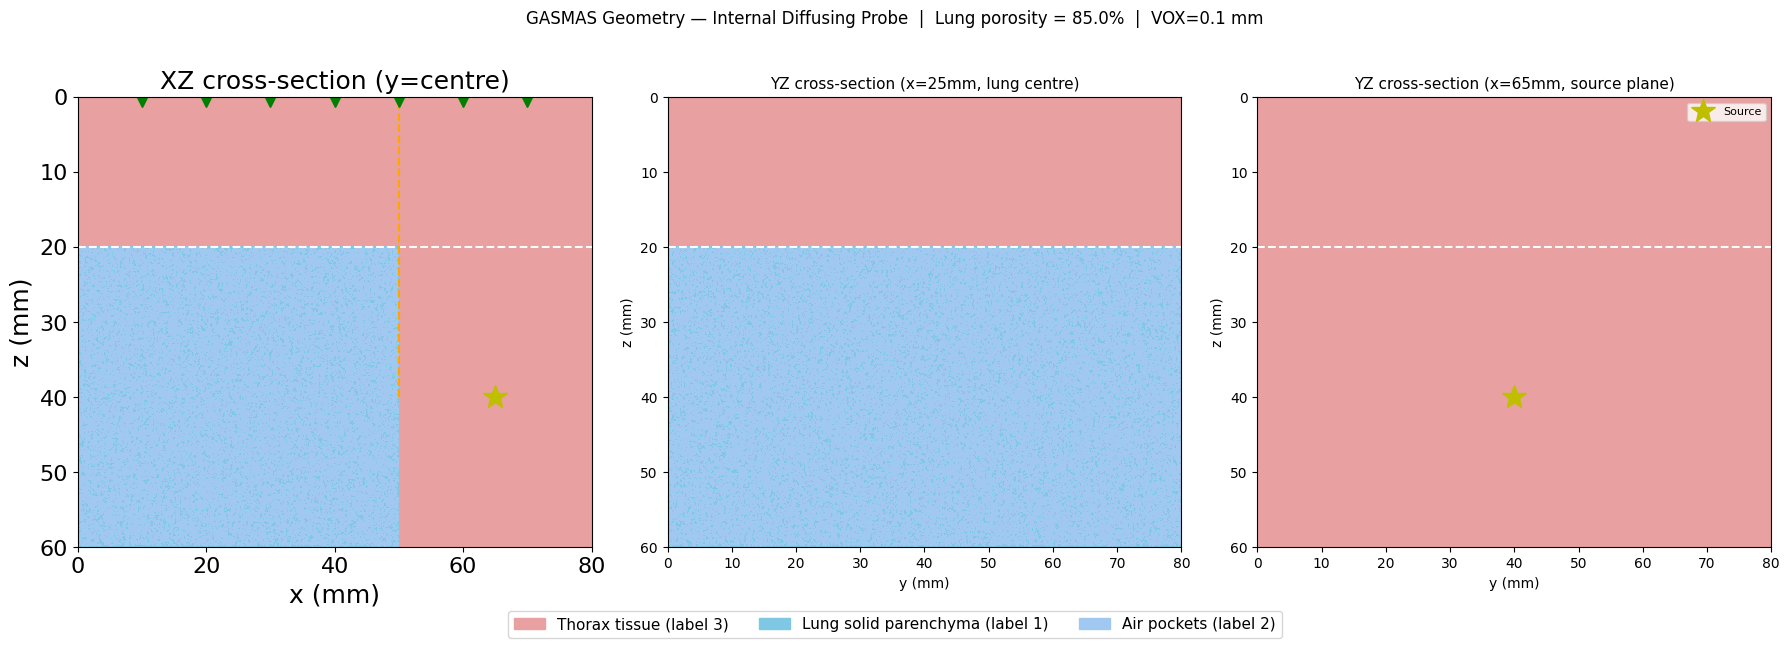

Thorax voxels : 224,000,000
Lung solid    : 24,000,000
Air voxels    : 136,000,000
Lung porosity : 85.00%


In [21]:
cmap_geo = mcolors.ListedColormap([
    '#f5f5f5',   # 0 background
    '#7ec8e3',   # 1 lung solid  — light blue
    '#a0c8f0',   # 2 air pocket  — lighter blue
    '#e8a0a0',   # 3 thorax      — pink/salmon
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XZ cross-section at y=centre
ax = axes[0]
sl = vol[:, NY//2, :].T
ax.imshow(sl, origin='lower', cmap=cmap_geo, vmin=0, vmax=3,
          extent=[0, PHYS_X, 0, PHYS_Z], interpolation='nearest', aspect='auto')
# Mark source
ax.plot(SRC_X_MM, SRC_Z_MM, 'y*', markersize=18, label='Source')
# Boundaries
ax.axhline(THORAX_TOP_MM, color='white', lw=1.5, ls='--', label='Thorax/lung boundary')
ax.axvline(THORAX_BOTTOM_X_MM, color='orange', lw=1.5, ls='--',
           ymin=THORAX_TOP_MM/PHYS_Z, label='Lung/thorax (bottom) split')
# Detectors
for dx in DET_X_MM_LIST:
    ax.plot(dx, 0, 'gv', markersize=15)
ax.plot([], [], 'gv', markersize=10, label='Detectors')
ax.set_xlabel('x (mm)', fontsize=18); ax.set_ylabel('z (mm)', fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('XZ cross-section (y=centre)', fontsize=18)
ax.invert_yaxis()   # z=0 at top (skin surface)

# ── YZ cross-section at x=25mm (lung centre) ──────────────────
ax = axes[1]
sl = vol[int(25/VOX_SIZE), :, :].T
ax.imshow(sl, origin='lower', cmap=cmap_geo, vmin=0, vmax=3,
          extent=[0, PHYS_Y, 0, PHYS_Z], interpolation='nearest', aspect='auto')
ax.axhline(THORAX_TOP_MM, color='white', lw=1.5, ls='--')
ax.set_xlabel('y (mm)'); ax.set_ylabel('z (mm)')
ax.set_title('YZ cross-section (x=25mm, lung centre)', fontsize=11)
ax.invert_yaxis()

# ── YZ cross-section at x=65mm (source plane) ─────────────────
ax = axes[2]
sl = vol[int(SRC_X_MM/VOX_SIZE), :, :].T
ax.imshow(sl, origin='lower', cmap=cmap_geo, vmin=0, vmax=3,
          extent=[0, PHYS_Y, 0, PHYS_Z], interpolation='nearest', aspect='auto')
ax.plot(SRC_Y_MM, SRC_Z_MM, 'y*', markersize=18, label='Source')
ax.axhline(THORAX_TOP_MM, color='white', lw=1.5, ls='--')
ax.set_xlabel('y (mm)'); ax.set_ylabel('z (mm)')
ax.set_title(f'YZ cross-section (x={SRC_X_MM:.0f}mm, source plane)', fontsize=11)
ax.invert_yaxis()
ax.legend(fontsize=8)

# ── Legend ────────────────────────────────────────────────────
patches = [
    mpatches.Patch(color='#e8a0a0', label='Thorax tissue (label 3)'),
    mpatches.Patch(color='#7ec8e3', label='Lung solid parenchyma (label 1)'),
    mpatches.Patch(color='#a0c8f0', label='Air pockets (label 2)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    f'GASMAS Geometry — Internal Diffusing Probe  |  '
    f'Lung porosity = {np.sum(vol==2)/(np.sum(vol==1)+np.sum(vol==2))*100:.1f}%  |  '
    f'VOX={VOX_SIZE} mm',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('geometry_internal_probe.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Thorax voxels : {np.sum(vol==3):,}')
print(f'Lung solid    : {np.sum(vol==1):,}')
print(f'Air voxels    : {np.sum(vol==2):,}')
print(f'Lung porosity : {np.sum(vol==2)/(np.sum(vol==1)+np.sum(vol==2))*100:.2f}%')


## Cell 6 — MCX Simulation (Internal Isotropic Source)

**Source type:** `'isotropic'` — MCX emits photons uniformly in all directions (4π sr).  
This models a diffusing-probe tip that randomises direction by scattering.

**Detectors:** Array of circular detectors on the top surface (z=1 vox), positioned at
different x positions spanning the thorax surface.

**`savedetflag = 'dp'`** — saves detector ID and per-medium pathlength per detected photon,
which is required for EAPL computation.

In [22]:
# Detector array on top surface
detpos = np.array([
    [dx / VOX_SIZE, DET_Y_VOX, DET_Z_VOX, DET_RADIUS_VOX]
    for dx in DET_X_MM_LIST
], dtype=float)

print('Source (isotropic diffusing probe):')
print(f'  pos = ({SRC_X_VOX:.0f}, {SRC_Y_VOX:.0f}, {SRC_Z_VOX:.0f}) vox'
      f' = ({SRC_X_MM}, {SRC_Y_MM}, {SRC_Z_MM}) mm')
print(f'  Label at source vox: {vol[int(SRC_X_VOX), int(SRC_Y_VOX), int(SRC_Z_VOX)]}')
print()
print(f'Detectors on top surface (z=1 vox = {VOX_SIZE} mm):')
print(f'  Radius: {DET_RADIUS_MM} mm  ({DET_RADIUS_VOX:.0f} vox)')
for i, (dx, dp) in enumerate(zip(DET_X_MM_LIST, detpos)):
    region = 'lung side' if dx < THORAX_BOTTOM_X_MM else 'thorax side'
    print(f'  Det {i+1}: x={dx:4.0f}mm  ({region})')

cfg = {
    'vol'         : vol,
    'unitinmm'    : VOX_SIZE,

    # Source: isotropic (diffusing probe)
    'srctype'     : 'isotropic',
    'srcpos'      : [SRC_X_VOX, SRC_Y_VOX, SRC_Z_VOX],
    'srcdir'      : [0, 0, 1],     # reference direction (ignored for isotropic)

    # Detectors
    'detpos'      : detpos,

    # Simulation settings
    'nphoton'     : NPHOTONS,
    'tstart'      : 0,
    'tend'        : 5e-9,
    'tstep'       : 5e-9,
    'prop'        : PROPS,
    'outputtype'  : 'fluence',
    'savedetflag' : 'dp',          # d=detID, p=pathlength per medium
    'seed'        : SEED,
    'isreflect'   : 1,             # handle refractive index mismatch at boundaries
    'bc'          : 'aaaaaa',      # absorbing boundaries all six faces
    'autopilot'   : 1,
    'maxdetphoton': NPHOTONS,
}

print(f'\nRunning MCX  ({NPHOTONS:,} photons)...')
t0      = time.time()
res     = pmcx.run(cfg)
elapsed = time.time() - t0

fluence = res['flux'][:, :, :, 0].astype(np.float32)
detp    = np.array(res['detp'])

print(f'Done in {elapsed:.1f}s  ({elapsed/60:.1f} min)')
print(f'Fluence shape : {fluence.shape}')
print(f'detp shape    : {detp.shape}')
print(f'  rows = {detp.shape[0]} fields per photon')
print(f'  cols = {detp.shape[1]:,} detected photons')

Source (isotropic diffusing probe):
  pos = (650, 400, 400) vox = (65.0, 40.0, 40.0) mm
  Label at source vox: 3

Detectors on top surface (z=1 vox = 0.1 mm):
  Radius: 2.5 mm  (25 vox)
  Det 1: x=  10mm  (lung side)
  Det 2: x=  20mm  (lung side)
  Det 3: x=  30mm  (lung side)
  Det 4: x=  40mm  (lung side)
  Det 5: x=  50mm  (thorax side)
  Det 6: x=  60mm  (thorax side)
  Det 7: x=  70mm  (thorax side)

Running MCX  (10,000,000 photons)...
nphoton: 1e+07
tstart: 0
tstep: 5e-09
tend: 5e-09
maxdetphoton: 1e+07
isreflect: 1
autopilot: 1
unitinmm: 0.1
Done in 173.3s  (2.9 min)
Fluence shape : (800, 800, 600)
detp shape    : (4, 28671)
  rows = 4 fields per photon
  cols = 28,671 detected photons


## Cell 7 — Pathlenght analysis

In [23]:
import numpy as np

# Parse detp
# detp rows: [detID, W, PL_label0, PL_label1, PL_label2, PL_label3, ...]
# Based on the detp shape (4, ...) and N_LABELS=4, it seems pathlength
# for label 0 (background) is skipped. So,
# detp[2,:] = pathlength for label 1 (lung tissue)
# detp[3,:] = pathlength for label 2 (air pockets)

N_LABELS  = PROPS.shape[0]   # 4
AIR_LABEL = 2                # label index for air pockets

det_ids    = detp[0, :].astype(int)   # 1-based detector indices
weights    = detp[1, :]               # photon weights
# Corrected index for pl_air assuming label 0 pathlength is skipped
pl_air     = detp[2 + (AIR_LABEL - 1), :]  # mm, per photon

print(f'Total detected photons : {detp.shape[1]:,}')
print(f'Unique detector IDs    : {np.unique(det_ids)}')
print()

EAPL_per_det = {}
N_det_per    = {}

for di, dx in enumerate(DET_X_MM_LIST, start=1):
    mask   = (det_ids == di)
    n_ph   = np.sum(mask)
    w_sum  = np.sum(weights[mask])

    if w_sum > 0:
        eapl = np.sum(weights[mask] * pl_air[mask]) / w_sum
    else:
        eapl = 0.0

    EAPL_per_det[dx] = eapl
    N_det_per[dx]    = n_ph
    region = 'lung side  ' if dx < THORAX_BOTTOM_X_MM else 'thorax side'
    print(f'  Det x={dx:4d}mm ({region}): {n_ph:6,} photons   EAPL = {eapl:.3f} mm')

det_x_arr  = np.array(DET_X_MM_LIST)
eapl_arr   = np.array([EAPL_per_det[dx] for dx in DET_X_MM_LIST])

Total detected photons : 28,671
Unique detector IDs    : [1 2 3 4 5 6 7]

  Det x=  10mm (lung side  ):    430 photons   EAPL = 5046.225 mm
  Det x=  20mm (lung side  ):  1,097 photons   EAPL = 5239.664 mm
  Det x=  30mm (lung side  ):  2,340 photons   EAPL = 5369.226 mm
  Det x=  40mm (lung side  ):  4,220 photons   EAPL = 5447.904 mm
  Det x=  50mm (thorax side):  6,815 photons   EAPL = 5915.136 mm
  Det x=  60mm (thorax side):  8,017 photons   EAPL = 6189.073 mm
  Det x=  70mm (thorax side):  5,752 photons   EAPL = 6614.562 mm


## Cell 10 — Save Results

In [ ]:
np.savez_compressed(
    'gasmas_internal_probe_results_30mm.npz',
    fluence    = fluence,
    detp       = detp,
)
print('Saved: gasmas_internal_probe_results.npz')

try:
    from google.colab import files
    files.download('gasmas_internal_probe_results_30mm.npz')
except ImportError:
    print('(Not in Colab — file is in the working directory)')

Saved: gasmas_internal_probe_results.npz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>